In [1]:
###hyperparameter tuning for better recall

import pandas as pd
import numpy as np
import joblib
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import recall_score, make_scorer
import warnings
warnings.filterwarnings('ignore')

#load data
X_train = joblib.load('data/X_train.pkl')
X_test = joblib.load('data/X_test.pkl')
y_train = joblib.load('data/y_train.pkl')
y_test = joblib.load('data/y_test.pkl')

print("Data loaded")
print(f"Training: {X_train.shape}")
print(f"Testing: {X_test.shape}")
print(f"Positive class: {y_train.mean()*100:.2f}%")

#calculate scale_pos_weight
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f"\nScale pos weight: {scale_pos_weight:.2f}")

C:\Users\User\AppData\Local\Temp\ipykernel_18620\2681038093.py:3: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


Data loaded
Training: (71236, 2431)
Testing: (30530, 2431)
Positive class: 11.16%

Scale pos weight: 7.96


In [2]:
#hyperparameter tuning
print("HYPERPARAMETER TUNING FOR XGBOOST")
print("_"*30)


def clean_feature_names(df):
    """Clean column names by removing invalid characters for XGBoost"""
    df = df.copy()
    df.columns = [str(col).replace('[', '_').replace(']', '_').replace('<', '_') 
                  for col in df.columns]
    return df

# Use the cleaned data 
if 'X_train_clean' not in locals():
    X_train_clean = clean_feature_names(X_train)
    X_test_clean = clean_feature_names(X_test)
    
#gefine paramter grid to test
param_grid = {
    'n_estimators':[100, 200],    #no of trees
    'max_depth': [4,6,8],     #tree depth
    'learning_rate':[0.05, 0.1],          #how fast to learn
    'min_child_weight':[1, 3 , 5]       #minimum samples in leaf
}

#create base model
xgb_base = XGBClassifier(
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)

#use Recall as scoring metric
recall_scorer = make_scorer(recall_score)

#grid search with 3-fold cross-validation
grid_search = GridSearchCV(
    estimator=xgb_base,
    param_grid=param_grid,
    scoring=recall_scorer,   #optimize for recall
    cv=3,      #3-fold cross-validation
    verbose=1,
    n_jobs=-1
)

print("Searching for best parameters...")

#fit grid search ----use subset for faster tuning
#use 50% of data for faster tuning
sample_size = int(len(X_train_clean) * 0.5)
X_train_sample = X_train_clean[:sample_size]
y_train_sample = y_train[:sample_size]

grid_search.fit(X_train_sample, y_train_sample)

print("\nTuning complete!")
print(f"\nBEST PARAMETERS:")
for param, value in grid_search.best_params_.items():
    print(f"   {param}: {value}")
print(f"\nBest Recall Score: {grid_search.best_score_:.4f}")

HYPERPARAMETER TUNING FOR XGBOOST
______________________________
Searching for best parameters...
Fitting 3 folds for each of 36 candidates, totalling 108 fits

Tuning complete!

BEST PARAMETERS:
   learning_rate: 0.05
   max_depth: 4
   min_child_weight: 5
   n_estimators: 100

Best Recall Score: 0.5614


In [3]:
#train optimized model
print("TRAINING OPTIMIZED XGBOOST MODEL")
print("="*30)

#get best parameters from grid search
best_params = grid_search.best_params_

best_xgb = XGBClassifier(
    n_estimators=grid_search.best_params_['n_estimators'],
    max_depth=grid_search.best_params_['max_depth'],
    learning_rate=grid_search.best_params_['learning_rate'],
    min_child_weight=grid_search.best_params_['min_child_weight'],
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss',
    n_jobs=-1
)

print("Training on full dataset...")
best_xgb.fit(X_train_clean, y_train)

print("Training complete!")



TRAINING OPTIMIZED XGBOOST MODEL
Training on full dataset...
Training complete!


In [4]:
#evaluate on test set
from sklearn.metrics import recall_score, precision_score, f1_score, roc_auc_score, accuracy_score

y_pred = best_xgb.predict(X_test_clean)
y_pred_proba = best_xgb.predict_proba(X_test_clean)[:,1]

print("\nOPTIMIZED MODEL PERFORMANCE:")
print(f"   Accuracy:  {accuracy_score(y_test, y_pred):.4f}")
print(f"   Recall:    {recall_score(y_test, y_pred):.4f} ({recall_score(y_test, y_pred)*100:.2f}%)")
print(f"   Precision: {precision_score(y_test, y_pred):.4f}")
print(f"   F1-Score:  {f1_score(y_test, y_pred):.4f}")
print(f"   ROC-AUC:   {roc_auc_score(y_test, y_pred_proba):.4f}")

#compare with previous model
print("\nIMPROVEMENT vs DEFAULT MODEL:")
print(f"   Default Recall: 0.5682 (56.82%)")
print(f"   Optimized Recall: {recall_score(y_test, y_pred):.4f} ({recall_score(y_test, y_pred)*100:.2f}%)")

# Save optimized model
joblib.dump(best_xgb, 'models/xgboost_optimized.pkl')
print("\nSaved: models/xgboost_optimized.pkl")


OPTIMIZED MODEL PERFORMANCE:
   Accuracy:  0.6444
   Recall:    0.6055 (60.55%)
   Precision: 0.1782
   F1-Score:  0.2754
   ROC-AUC:   0.6707

IMPROVEMENT vs DEFAULT MODEL:
   Default Recall: 0.5682 (56.82%)
   Optimized Recall: 0.6055 (60.55%)

Saved: models/xgboost_optimized.pkl


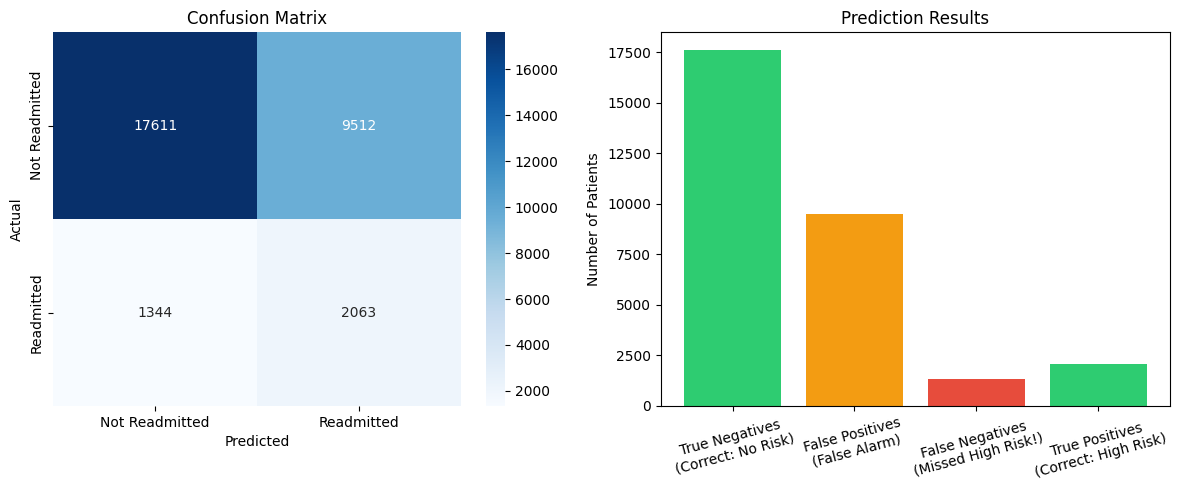


INTERPRETATION:
   -- Correctly identified HIGH RISK: 2,063 patients
   -- Missed HIGH RISK patients: 1,344 patients (DANGEROUS!)
   -- False alarms (said HIGH RISK but were not): 9,512 patients


In [11]:
#confusion matrix visualization
from sklearn.metrics import confusion_matrix
import seaborn as sns


#calculate confusion matrix
cm = confusion_matrix(y_test, y_pred)

#visualization
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

#heatmap
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')
axes[0].set_title('Confusion Matrix')
axes[0].set_xticklabels(['Not Readmitted', 'Readmitted'])
axes[0].set_yticklabels(['Not Readmitted', 'Readmitted'])

#bar chart predictions
labels = ['True Negatives\n(Correct: No Risk)', 
          'False Positives\n(False Alarm)',
          'False Negatives\n(Missed High Risk!)', 
          'True Positives\n(Correct: High Risk)']
values = [cm[0,0], cm[0,1], cm[1,0], cm[1,1]]
colors = ['#2ecc71', '#f39c12', '#e74c3c', '#2ecc71']

axes[1].bar(labels, values, color=colors)
axes[1].set_ylabel('Number of Patients')
axes[1].set_title('Prediction Results')
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.savefig('outputs/confusion_matrix_optimized.png', dpi=100, bbox_inches='tight')
plt.show()

print("\nINTERPRETATION:")
print(f"   -- Correctly identified HIGH RISK: {cm[1,1]:,} patients")
print(f"   -- Missed HIGH RISK patients: {cm[1,0]:,} patients (DANGEROUS!)")
print(f"   -- False alarms (said HIGH RISK but were not): {cm[0,1]:,} patients")

 SHAP ANALYSIS - Explaining Predictions
creating SHAP explainer....
SHAP values calculated!


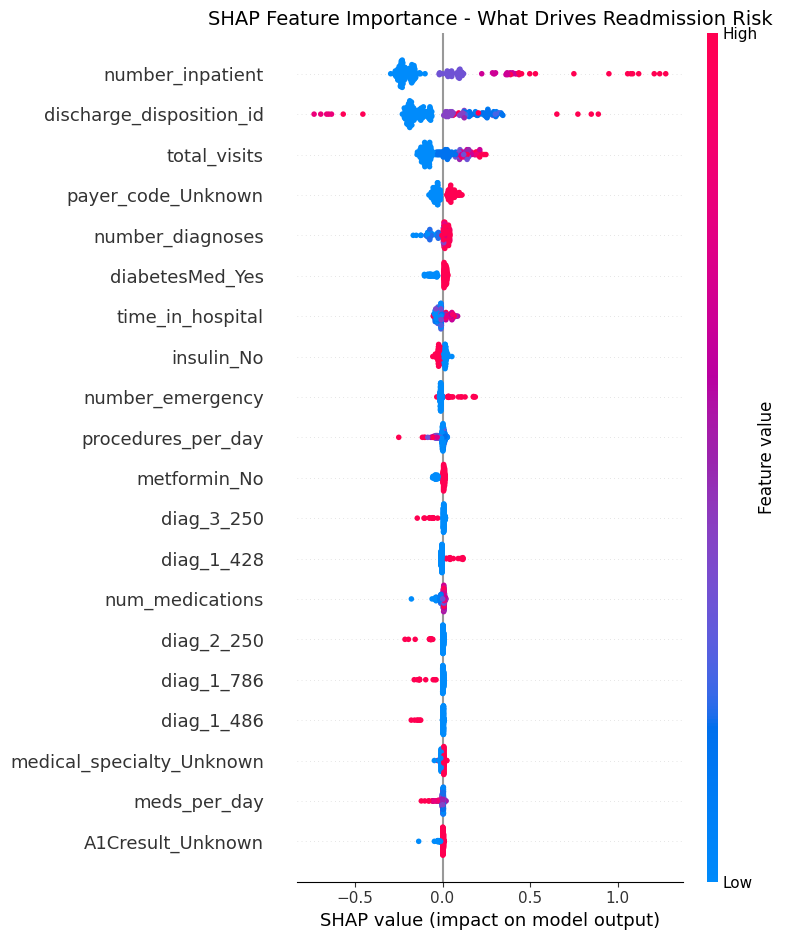

Saved: outputs/shap_summary_optimized.png


In [15]:
##SHAP analysis------understand model decisions
# !pip install shap
import shap

print(" SHAP ANALYSIS - Explaining Predictions")
print("="*40)

#use sample of test data for SHAP
X_sample = X_test_clean.sample(n=200, random_state=42)

print("creating SHAP explainer....")
explainer=shap.TreeExplainer(best_xgb)
shap_values = explainer.shap_values(X_sample)

print("SHAP values calculated!")

# Summary plot
plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values, X_sample, show=False)
plt.title('SHAP Feature Importance - What Drives Readmission Risk', fontsize=14)
plt.tight_layout()
plt.savefig('outputs/shap_summary_optimized.png', dpi=100, bbox_inches='tight')
plt.show()
print("Saved: outputs/shap_summary_optimized.png")

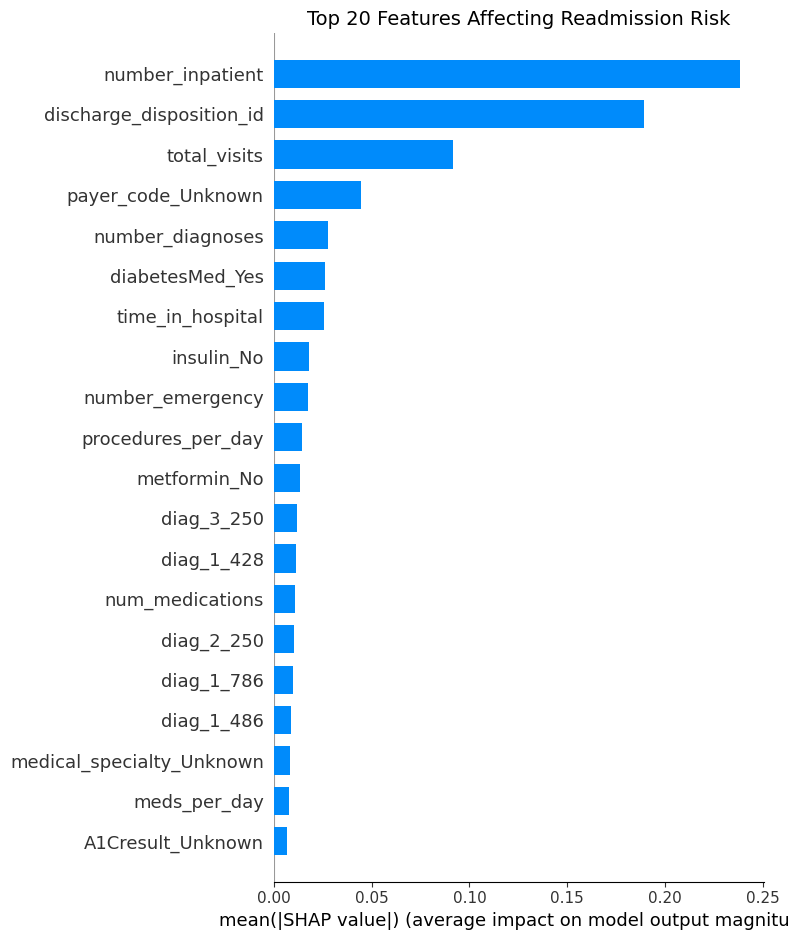

Saved: outputs/shap_top_features_optimized.png

TOP 10 MOST IMPORTANT FEATURES:
----------------------------------------
   10. number_inpatient                                        : 0.2384
   2. discharge_disposition_id                                : 0.1891
   12. total_visits                                            : 0.0915
   49. payer_code_Unknown                                      : 0.0445
   11. number_diagnoses                                        : 0.0276
   2431. diabetesMed_Yes                                         : 0.0262
   4. time_in_hospital                                        : 0.0260
   2420. insulin_No                                              : 0.0181
   9. number_emergency                                        : 0.0174
   14. procedures_per_day                                      : 0.0143


In [17]:
#top 20 features bar plot
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_sample, plot_type="bar", show=False)
plt.title('Top 20 Features Affecting Readmission Risk', fontsize=14)
plt.tight_layout()
plt.savefig('outputs/shap_top_features_optimized.png', dpi=100, bbox_inches='tight')
plt.show()
print("Saved: outputs/shap_top_features_optimized.png")

#top 10 features
feature_importance = np.abs(shap_values).mean(axis=0)
feature_names = X_sample.columns
importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': feature_importance
}).sort_values('importance', ascending=False)

print("\nTOP 10 MOST IMPORTANT FEATURES:")
print("-"*40)
for i, row in importance_df.head(10).iterrows():
    print(f"   {i+1}. {row['feature'][:55]:55s} : {row['importance']:.4f}")

EXAMPLE: Explaining a High-Risk Patient

PATIENT #10
   Readmission Risk Score: 53.4%
   Actual outcome: Readmitted within 30 days
   Model prediction: HIGH RISK - CORRECT


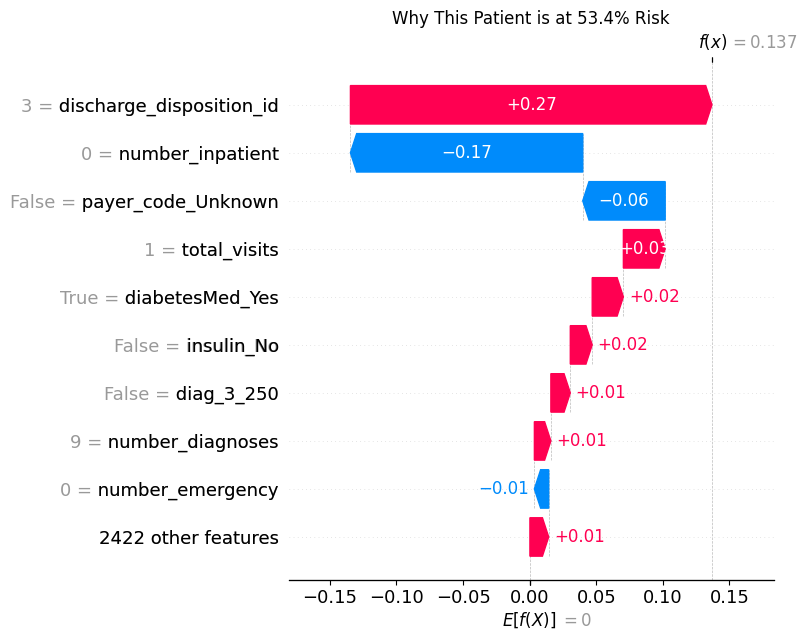


 Saved: outputs/patient_explanation_optimized.png

 HOW TO READ THIS CHART:
    Red bars = Features that INCREASE readmission risk
    Blue bars = Features that DECREASE readmission risk
    Bar length = How much impact the feature has


In [18]:
#explaining a high-risk patient
print("EXAMPLE: Explaining a High-Risk Patient")
print("="*60)

#find patients correctly predicted as high-risk
y_pred_test = best_xgb.predict(X_test_clean)
high_risk_correct = (y_pred_test == 1) & (y_test == 1)

if high_risk_correct.sum() > 0:
    #get first high-risk patient
    patient_idx = np.where(high_risk_correct)[0][0]
    patient_data = X_test_clean.iloc[patient_idx:patient_idx+1]
    patient_risk = best_xgb.predict_proba(patient_data)[0, 1]

    print(f"\nPATIENT #{patient_idx}")
    print(f"   Readmission Risk Score: {patient_risk*100:.1f}%")
    print(f"   Actual outcome: Readmitted within 30 days")
    print(f"   Model prediction: HIGH RISK - CORRECT")
    
    # Get SHAP explanation
    explainer_local = shap.TreeExplainer(best_xgb)
    shap_values_patient = explainer_local.shap_values(patient_data)

    #create waterfall plot
    plt.figure(figsize=(10, 6))
    shap.waterfall_plot(
        shap.Explanation(
            values=shap_values_patient[0],
            base_values=explainer.expected_value,
            data=patient_data.iloc[0],
            feature_names=patient_data.columns.tolist()
        ),
        show=False,
        max_display=10
    )
    plt.title(f'Why This Patient is at {patient_risk*100:.1f}% Risk', fontsize=12)
    plt.tight_layout()
    plt.savefig('outputs/patient_explanation_optimized.png', dpi=100, bbox_inches='tight')
    plt.show()

    print("\n Saved: outputs/patient_explanation_optimized.png")
    print("\n HOW TO READ THIS CHART:")
    print("    Red bars = Features that INCREASE readmission risk")
    print("    Blue bars = Features that DECREASE readmission risk")
    print("    Bar length = How much impact the feature has")
else:
    print("No high-risk patients found in sample")

In [24]:
#risk prediction function
import pandas as pd
import numpy as np
import shap
import joblib

def predict_readmission_risk(patient_data, model=best_xgb):
    """
    Predict readmission risk for a patient
    
    Parameters:
    - patient_data: DataFrame with same features as training data
    - model: Trained XGBoost model
    
    Returns:
    - Dictionary with risk score, risk level, and top factors
    """
    
    #clean feature names
    if hasattr(patient_data, 'columns'):
        patient_data = clean_feature_names(patient_data)
    
    #convert all columns to numeric- error fix
    for col in patient_data.columns:
        if patient_data[col].dtype == 'object':
            patient_data[col] = pd.to_numeric(patient_data[col], errors='coerce').fillna(0)
    
    patient_data = patient_data.astype(np.float32)
    
    #get risk probability
    risk_score = model.predict_proba(patient_data)[0, 1] * 100
    
    # determine risk level and action
    if risk_score >= 70:
        risk_level = " HIGH RISK - Immediate intervention needed"
        recommended_action = "Schedule follow-up within 3 days, home health visit"
    elif risk_score >= 40:
        risk_level = " MEDIUM RISK - Monitor closely"
        recommended_action = "Schedule follow-up within 7 days, medication review"
    else:
        risk_level = " LOW RISK - Standard care"
        recommended_action = "Standard discharge procedure"
    
    # get SHAP explanation for this patient
    try:
        explainer_local = shap.TreeExplainer(model)
        shap_values = explainer_local.shap_values(patient_data)
        
        #get top 3 features increasing risk
        feature_impacts = pd.DataFrame({
            'feature': patient_data.columns,
            'impact': shap_values[0]
        })
        feature_impacts = feature_impacts.sort_values('impact', ascending=False)
        top_increasing = feature_impacts.head(3)
        
        top_factors = top_increasing[['feature', 'impact']].to_dict('records')
    except Exception as e:
        print(f"SHAP explanation failed: {e}")
        top_factors = [{'feature': 'N/A', 'impact': 0}]
    
    return {
        'risk_score': round(risk_score, 1),
        'risk_level': risk_level,
        'recommended_action': recommended_action,
        'top_risk_factors': top_factors
    }


###testing function
print("TESTING RISK PREDICTION FUNCTION")
print("_"*60)

test_patients = X_test_clean.head(3).copy()

#convert test data to numeric (if not)
for col in test_patients.columns:
    if test_patients[col].dtype == 'object':
        test_patients[col] = pd.to_numeric(test_patients[col], errors='coerce').fillna(0)

test_patients = test_patients.astype(np.float32)

# Test on each patient
for i, (idx, patient) in enumerate(test_patients.iterrows()):
    result = predict_readmission_risk(patient.to_frame().T)
    
    print(f"\n{'='*50}")
    print(f"PATIENT {i+1}")
    print(f"{'='*50}")
    print(f"   -- Risk Score: {result['risk_score']}%")
    print(f"   {result['risk_level']}")
    print(f"   -- Recommended Action: {result['recommended_action']}")
    print(f"   -- Top Risk Factors:")
    for factor in result['top_risk_factors']:
        print(f"      - {factor['feature'][:50]}: +{factor['impact']:.4f}")

print("\n" + "_"*60)
print("Risk prediction function is READY!")
print("-"*60)

TESTING RISK PREDICTION FUNCTION
____________________________________________________________

PATIENT 1
   -- Risk Score: 51.3%
    MEDIUM RISK - Monitor closely
   -- Recommended Action: Schedule follow-up within 7 days, medication review
   -- Top Risk Factors:
      - discharge_disposition_id: +0.2815
      - time_in_hospital: +0.0477
      - diabetesMed_Yes: +0.0221

PATIENT 2
   -- Risk Score: 66.5%
    MEDIUM RISK - Monitor closely
   -- Recommended Action: Schedule follow-up within 7 days, medication review
   -- Top Risk Factors:
      - number_inpatient: +0.5158
      - total_visits: +0.1530
      - payer_code_Unknown: +0.0529

PATIENT 3
   -- Risk Score: 40.6%
    MEDIUM RISK - Monitor closely
   -- Recommended Action: Schedule follow-up within 7 days, medication review
   -- Top Risk Factors:
      - discharge_disposition_id: +0.0916
      - payer_code_Unknown: +0.0221
      - number_diagnoses: +0.0097

____________________________________________________________
Risk predi

In [26]:
#save
import joblib
import pandas as pd
import numpy as np

print("SAVING FILES FOR HOSPITAL DASHBOARD")
print("="*60)

#save the optimized model
joblib.dump(best_xgb, 'models/final_hospital_model.pkl')
print("Saved: models/final_hospital_model.pkl")

# Save feature names
feature_names = X_train_clean.columns.tolist()
joblib.dump(feature_names, 'models/feature_names.pkl')
print("Saved: models/feature_names.pkl")

# Save a sample patient for testing
sample_patient = X_test_clean.head(1).copy()

# Convert to numeric
for col in sample_patient.columns:
    if sample_patient[col].dtype == 'object':
        sample_patient[col] = pd.to_numeric(sample_patient[col], errors='coerce').fillna(0)
sample_patient = sample_patient.astype(np.float32)
joblib.dump(sample_patient, 'models/sample_patient.pkl')
print("Saved: models/sample_patient.pkl")

#save the clean feature names list
feature_list = pd.DataFrame({
    'feature_name': X_train_clean.columns.tolist(),
    'feature_type': X_train_clean.dtypes.astype(str).tolist()
})
feature_list.to_csv('models/feature_list.csv', index=False)
print("Saved: models/feature_list.csv")

print("\n" + "="*60)
print("ALL FILES SAVED SUCCESSFULLY!")
print("="*60)


SAVING FILES FOR HOSPITAL DASHBOARD
Saved: models/final_hospital_model.pkl
Saved: models/feature_names.pkl
Saved: models/sample_patient.pkl
Saved: models/feature_list.csv

ALL FILES SAVED SUCCESSFULLY!
